# Ajedrez online: ELO, apertura y ritmo como predictores del resultado
### Entrega 1 · Ingeniería de datos

**Proyecto Integrador — Ciencia de Datos, UTN FRM 2026**

---

**Pregunta de investigación.** ¿En qué medida el rating informado, la modalidad de ritmo de juego y —una vez identificada— la apertura permiten predecir el resultado y la longitud (en medio-movimientos) de una partida de ajedrez *rated* en Chess.com, y qué ventaja estimada tiene jugar con blancas al controlar por diferencia de rating?

**Unidad de análisis.** Una partida individual de ajedrez estándar y *rated* jugada en Chess.com.

**Fuente.** [PubAPI pública de Chess.com](https://www.chess.com/news/view/published-data-api), sin autenticación ni API key. Se descargan los archivos mensuales de 100 cuentas públicas, 20 por cada banda de ELO, en serie, tal como recomienda la documentación oficial. La lista de cuentas la arma una sola vez la tarea `listar_jugadores` del DAG y después queda congelada.

**Qué hace este notebook.** Ejecuta el pipeline completo — descarga, parseo, limpieza, ingeniería de features y exportación — contra la API real, sin datos simulados ni pasos manuales. Cierra con dos secciones que documentan explícitamente las limitaciones metodológicas de la fuente (Sección 6) y el alcance real de la muestra (Sección 8), para que el modelado de Entrega 3 parta de premisas correctas.

| | |
|---|---|
| **Entregable** | `data/processed/partidas_ajedrez_clean.parquet` |
| **Target de clasificación** | `resultado` — Gana Blancas / Gana Negras / Empate |
| **Target de regresión** | `cantidad_jugadas` — longitud en medio-movimientos (plies) |
| **Target secundario** | `es_sorpresa` — ganó el jugador con menor rating |

## 1 · Configuración e imports

In [1]:
# The notebook's working directory is switched to the repo root so that the
# relative paths in config.yaml (data/raw, data/processed) resolve the same
# way whether the pipeline runs from the notebook or from `python -m src.pipeline`.
import logging
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Ensures accented characters print correctly regardless of the OS console codepage.
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

REPO_ROOT = Path("..").resolve()
if Path.cwd() != REPO_ROOT:
    os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from src.clean_data import DataCleaner
from src.download_data import DataDownloader
from src.feature_engineering import FeatureEngineer
from src.player_selection import load_or_create_selection
from src.utils import load_config

# Silence the pipeline's step-by-step INFO logging: this notebook narrates the
# same steps in markdown, so per-request progress logs would just be noise.
for _name in ["src.download_data", "src.clean_data", "src.feature_engineering"]:
    logging.getLogger(_name).setLevel(logging.WARNING)

# Shared look for every chart in the notebook: one accent color, a light grid,
# no top/right spines, consistent sizing.
ACCENT = "#3d5a45"
ACCENT_SOFT = "#8fae94"
INK = "#2a2a28"
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c9c4b8",
    "axes.labelcolor": INK,
    "axes.titlelocation": "left",
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e7e3d8",
    "grid.linewidth": 0.8,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 10.5,
    "font.family": "sans-serif",
})
pd.set_option("display.max_columns", 30)

config = load_config("config/config.yaml")
config["player_selection"]["pools"]

{'titulados_avanzado': {'titles': ['FM', 'CM', 'NM'], 'bands': ['avanzado']},
 'titulados_alto': {'titles': ['GM', 'IM'],
  'bands': ['experto', 'top_mundial']},
 'paises': {'countries': ['AR', 'ES', 'MX', 'US', 'IN', 'BR', 'DE', 'RU'],
  'bands': ['principiante', 'intermedio']}}

## 2 · Descarga automatizada

`DataDownloader` consulta primero `/pub/player/{username}/games/archives` y luego los archivos mensuales `/games/{YYYY}/{MM}`. Recorre los meses en orden descendente hasta reunir como máximo 1.000 partidas *rated* de ajedrez estándar en bullet, blitz o rapid por usuario.

La ventana temporal está **congelada** en `config.yaml` (`download.until_month: "2026-08"`): se ignoran los archivos posteriores a agosto de 2026, de modo que una corrida desde cero reproduce exactamente el mismo dataset en vez de arrastrar los meses nuevos.

Las solicitudes se hacen en serie: la documentación oficial de Chess.com es explícita en que el acceso serial no tiene límite (*"if you always wait to receive the response to your previous request before making your next request, then you should never encounter rate limiting"*), mientras que las solicitudes concurrentes sí pueden recibir `429 Too Many Requests`. La lista de jugadores no está en `config.yaml`: sale de la selección congelada (`data/raw/seleccion/jugadores_seleccionados.yaml`) que arma la primera corrida, así que el notebook descarga exactamente las mismas cuentas que el DAG. La descarga es además idempotente (si el JSON de un usuario ya existe en `data/raw/`, se saltea) y tolerante a fallos aislados: si una cuenta falla —404 por cuenta borrada, sin partidas— se registra un aviso y se sigue con el resto, exigiendo al final un mínimo de usuarios y de partidas totales.

In [2]:
# The player list is not in config.yaml: it is the frozen selection that the DAG's
# listar_jugadores task creates once (data/raw/seleccion/jugadores_seleccionados.yaml).
# Reading it here downloads exactly the same accounts as the DAG.
jugadores = load_or_create_selection(config)
print(f"Jugadores de la selección congelada: {len(jugadores)}")

downloader = DataDownloader(config)
raw_paths = downloader.download_all(jugadores)
len(raw_paths)

2026-09-26 13:00:46 - src.player_selection - INFO - Selección congelada reutilizada (data\raw\seleccion\jugadores_seleccionados.yaml): 100 jugadores


Jugadores de la selección congelada: 100


100

## 3 · Parseo y limpieza

Cada objeto JSON trae metadata estructurada y una representación PGN completa. `DataCleaner` combina ambas: toma del JSON el identificador, la modalidad y la variante; del PGN extrae jugadores, ratings, resultado, ECO, terminación y jugadas. También deduplica por `GameUrl`, porque más de una de las cuentas configuradas puede aparecer en la misma partida si juegan entre sí.

El filtro de validez exige, además de resultado y ratings no nulos, variante estándar, modalidad dentro del universo del proyecto, partida *rated*, **fecha parseable** y **al menos 5 medio-movimientos jugados**. Sin el umbral de jugadas quedan en el dataset partidas degeneradas — un jugador se desconecta o abandona en la primera o segunda jugada — que Chess.com igual marca como *rated* con resultado, pero que no son partidas jugadas en ningún sentido útil para modelar resultado o longitud. El chequeo de fecha descarta las pocas partidas donde Chess.com emite `Date` incompleta (`"????.??.??"`), en vez de dejar que un nulo se cuele al dataset final.

`Termination` viene con el username del ganador embebido (`"Fulano won by resignation"`), lo que la vuelve casi un identificador; se normaliza al motivo puro (`resignation`, `time`, `checkmate`, …). Las tablas por bandera con material insuficiente (`timeout vs insufficient material`) se marcan en su propia categoría, no como `time`, porque son un empate y no una victoria por tiempo.

In [3]:
cleaner = DataCleaner(config)
df, raw_row_count = cleaner.clean(raw_paths)
df = cleaner.optimize_dtypes(df)

print(f"Partidas descargadas: {raw_row_count:,}")
print(f"Partidas válidas: {len(df):,} ({100 * len(df) / raw_row_count:.2f}% retenidas)")
df.head()

Partidas descargadas: 77,229
Partidas válidas: 76,803 (99.45% retenidas)


,GameUrl,Event,Date,White,Black,Result,WhiteElo,BlackElo,Variant,TimeControl,TimeClass,ECO,Opening,Termination,Rated,moves_text,TournamentUrl,StartTime,EndTime,resultado,tiempo_base_seg,incremento_seg,cantidad_jugadas,EsTorneo
0,https://www.chess.com/game/live/173803284094,Live Chess,2026-08-31,PreddyBoh,Agdakaoana,1-0,164,145,Standard,300,blitz,C10,French Defense Normal Variation 2,checkmate,True,1. d4 1... d5 2. Nc3 2... Nc6 3. Nf3 3... e6 4...,<NA>,2026-08-31 17:16:42+00:00,2026-08-31 17:25:16+00:00,Gana Blancas,300,0.0,91,False
1,https://www.chess.com/game/live/173803204748,Live Chess,2026-08-31,rxmbo_08,Agdakaoana,1-0,175,153,Standard,300,blitz,C20,Kings Pawn Opening 1,resignation,True,1. e4 1... e5 2. Qh5 2... Nh6 3. Qxe5+ 3... Be...,<NA>,2026-08-31 17:14:56+00:00,2026-08-31 17:16:37+00:00,Gana Blancas,300,0.0,19,False
2,https://www.chess.com/game/live/173802707510,Live Chess,2026-08-31,Agdakaoana,joerr0622,1-0,161,128,Standard,300,blitz,A40,Queens Pawn Opening,time,True,1. d4 1... a5 2. Nc3 2... h5 3. e4 3... e5 4. ...,<NA>,2026-08-31 17:03:52+00:00,2026-08-31 17:11:32+00:00,Gana Blancas,300,0.0,55,False
3,https://www.chess.com/game/live/173802500366,Live Chess,2026-08-31,Agdakaoana,strawberiies09,1-0,153,158,Standard,300,blitz,C40,Kings Pawn Opening Kings Knight Variation,resignation,True,1. e4 1... e5 2. Nf3 2... Qf6 3. d4 3... Bb4+ ...,<NA>,2026-08-31 16:59:17+00:00,2026-08-31 17:02:11+00:00,Gana Blancas,300,0.0,27,False
4,https://www.chess.com/game/live/173765622822,Live Chess,2026-08-30,KIRKIFICATION_HOUR,Agdakaoana,1-0,315,280,Standard,600,rapid,B07,Pirc Defense Modern Defense Geller System 2,checkmate,True,1. e4 1... e5 2. Nf3 2... d6 3. Bc4 3... Nf6 4...,<NA>,2026-08-30 21:16:41+00:00,2026-08-30 21:28:57+00:00,Gana Blancas,600,0.0,69,False


## 4 · Ingeniería de features

`FeatureEngineer.transform` agrega, todo vectorizado:

- `diferencia_elo`, `elo_promedio`: comparación de rating. **Ver Sección 6.A sobre la limitación de este rating.**
- `nivel_promedio`: banda de ELO de la partida, de principiante a top mundial (umbrales configurados en `config/config.yaml`, no son un estándar oficial de Chess.com — son una segmentación propia del proyecto para EDA).
- `es_sorpresa`: 1 si ganó el jugador con menor rating informado. Se calcula directamente con el signo de `diferencia_elo`; cuando ambos ratings son iguales vale 0.
- `familia_apertura`: agrupa el código ECO en las 5 familias oficiales de la Encyclopaedia of Chess Openings — A *(flanco)*, B *(semiabiertas, incluye Caro-Kann)*, C *(abiertas, incluye Francesa)*, D *(cerradas)*, E *(india)*. **Ver Sección 6.B sobre por qué esta variable no es utilizable en un modelo estrictamente pre-partida.**

In [4]:
engineer = FeatureEngineer(config)
df = engineer.transform(df)
df.head()

,GameUrl,Event,Date,White,Black,Result,WhiteElo,BlackElo,Variant,TimeControl,TimeClass,ECO,Opening,Termination,Rated,moves_text,TournamentUrl,StartTime,EndTime,resultado,tiempo_base_seg,incremento_seg,cantidad_jugadas,EsTorneo,diferencia_elo,elo_promedio,nivel_promedio,es_sorpresa,familia_apertura
0,https://www.chess.com/game/live/173803284094,Live Chess,2026-08-31,PreddyBoh,Agdakaoana,1-0,164,145,Standard,300,blitz,C10,French Defense Normal Variation 2,checkmate,True,1. d4 1... d5 2. Nc3 2... Nc6 3. Nf3 3... e6 4...,<NA>,2026-08-31 17:16:42+00:00,2026-08-31 17:25:16+00:00,Gana Blancas,300,0.0,91,False,19,154.5,principiante,0,Abierta
1,https://www.chess.com/game/live/173803204748,Live Chess,2026-08-31,rxmbo_08,Agdakaoana,1-0,175,153,Standard,300,blitz,C20,Kings Pawn Opening 1,resignation,True,1. e4 1... e5 2. Qh5 2... Nh6 3. Qxe5+ 3... Be...,<NA>,2026-08-31 17:14:56+00:00,2026-08-31 17:16:37+00:00,Gana Blancas,300,0.0,19,False,22,164.0,principiante,0,Abierta
2,https://www.chess.com/game/live/173802707510,Live Chess,2026-08-31,Agdakaoana,joerr0622,1-0,161,128,Standard,300,blitz,A40,Queens Pawn Opening,time,True,1. d4 1... a5 2. Nc3 2... h5 3. e4 3... e5 4. ...,<NA>,2026-08-31 17:03:52+00:00,2026-08-31 17:11:32+00:00,Gana Blancas,300,0.0,55,False,33,144.5,principiante,0,Flanco
3,https://www.chess.com/game/live/173802500366,Live Chess,2026-08-31,Agdakaoana,strawberiies09,1-0,153,158,Standard,300,blitz,C40,Kings Pawn Opening Kings Knight Variation,resignation,True,1. e4 1... e5 2. Nf3 2... Qf6 3. d4 3... Bb4+ ...,<NA>,2026-08-31 16:59:17+00:00,2026-08-31 17:02:11+00:00,Gana Blancas,300,0.0,27,False,-5,155.5,principiante,1,Abierta
4,https://www.chess.com/game/live/173765622822,Live Chess,2026-08-30,KIRKIFICATION_HOUR,Agdakaoana,1-0,315,280,Standard,600,rapid,B07,Pirc Defense Modern Defense Geller System 2,checkmate,True,1. e4 1... e5 2. Nf3 2... d6 3. Bc4 3... Nf6 4...,<NA>,2026-08-30 21:16:41+00:00,2026-08-30 21:28:57+00:00,Gana Blancas,600,0.0,69,False,35,297.5,principiante,0,Semiabierta


### Diccionario de datos

| Columna | Tipo | Descripción |
|---|---|---|
| `GameUrl` | str | URL única de la partida; se usa para deduplicar. |
| `Date` | datetime | Fecha (día UTC de inicio) de la partida. |
| `StartTime`, `EndTime` | datetime UTC | Inicio (headers `UTCDate` + `UTCTime`) y fin (`end_time` del JSON) con hora exacta: ordenan causalmente partidas del mismo día. |
| `TournamentUrl`, `EsTorneo` | str / bool | URL del torneo de Chess.com (nula si no es de torneo) y su indicador. `Event` vale siempre `Live Chess`, así que es la única traza del mecanismo de emparejamiento. |
| `White`, `Black` | str | Username de cada jugador (solo control/auditoría, no features de modelo). |
| `Result`, `Variant`, `Rated`, `Event` | str/bool/cat | Campos crudos; constantes tras el filtro (`Standard`, `True`, `Live Chess`). Se conservan como traza de auditoría. |
| `WhiteElo`, `BlackElo` | int | Rating informado por Chess.com al cierre de la partida. |
| `diferencia_elo` | int | `WhiteElo - BlackElo`. |
| `elo_promedio` | float | Rating promedio de ambos jugadores. |
| `nivel_promedio` | category | Banda de rating (principiante a top mundial). |
| `tiempo_base_seg`, `incremento_seg` | int | Componentes del control de tiempo. |
| `ECO`, `Opening` | category | Código y nombre de la apertura. `Opening` vale `"Undefined"` cuando Chess.com no la identificó (ver Sección 6.C). |
| `familia_apertura` | category | Familia ECO (flanco / semiabierta / abierta / cerrada / india). |
| `Termination` | category | Motivo de finalización normalizado (resignation, time, checkmate, ...). |
| `resultado` | category | **Target de clasificación.** Gana Blancas / Gana Negras / Empate. |
| `cantidad_jugadas` | int | **Target de regresión.** Longitud de la partida en plies. |
| `es_sorpresa` | int8 | **Target secundario.** 1 si ganó el jugador con menor rating. |

## 5 · Exportación

Se guarda el dataset final en Parquet (compresión `snappy`), un sample CSV para inspección rápida y `data_summary.json` con métricas de volumen, targets y nulos.

In [5]:
processed_dir = Path(config["paths"]["processed_dir"])
processed_dir.mkdir(parents=True, exist_ok=True)

clean_parquet_path = Path(config["paths"]["clean_parquet"])
df.to_parquet(clean_parquet_path, engine="pyarrow", compression="snappy", index=False)

sample_path = Path(config["paths"]["clean_sample_csv"])
sample_size = min(config["processing"]["sample_size"], len(df))
df.sample(n=sample_size, random_state=config["processing"]["random_state"]).to_csv(
    sample_path, index=False
)

print(f"Dataset final: {clean_parquet_path}")
print(f"Sample de validación ({sample_size:,} filas): {sample_path}")

Dataset final: data\processed\partidas_ajedrez_clean.parquet
Sample de validación (5,000 filas): data\processed\partidas_ajedrez_clean_sample.csv


## 6 · Limitaciones de la fuente

Dos limitaciones metodológicas de fondo de la PubAPI de Chess.com condicionan cómo se puede usar este dataset a partir de Entrega 3, más una nota sobre la cobertura de la apertura. Se documentan acá, con datos, en vez de dejarlas implícitas.

### 6.A — El rating informado es posterior a la partida, no anterior

Chess.com informa en cada partida el rating Glicko del jugador **después** de que el resultado lo ajustó, no un snapshot estrictamente previo. Es una diferencia real frente a Lichess, cuya API sí expone el rating previo a la partida (junto con el ajuste posterior en un campo separado, `WhiteRatingDiff`/`BlackRatingDiff`).

Esto significa que `WhiteElo`, `BlackElo` y todo lo que se deriva de ellos (`diferencia_elo`, `elo_promedio`, `nivel_promedio`, `es_sorpresa`) contienen una fuga de información hacia `resultado`: el propio resultado ya está incorporado, en una magnitud pequeña, en el rating que se usaría para predecirlo. El efecto es chico en términos absolutos (el ajuste típico de Glicko por una sola partida es de pocos puntos en jugadores establecidos), pero se concentra justo en las partidas de rating parejo — que es donde más importa para estimar la ventaja de jugar con blancas controlando por diferencia de fuerza.

No hay forma de obtener el rating estrictamente previo desde este endpoint sin reconstruir el historial cronológico completo de cada jugador. Para Entrega 3 esto se declara como limitación conocida de la fuente, no se oculta ni se corrige con un parche improvisado.

### 6.B — La apertura no existe antes de que empiece la partida

La pregunta de investigación busca predictores disponibles *antes* de que se juegue la partida. El rating informado, la modalidad y el control de tiempo cumplen esa condición: existen en el momento en que la partida se crea. La apertura no: recién se identifica después de que ambos jugadores hicieron sus primeras jugadas.

Por eso el modelado de Entrega 3 se plantea en dos escenarios separados, no en uno solo:

- **Modelo pre-partida**: rating, diferencia de rating, `TimeClass` y control de tiempo.
- **Modelo post-apertura**: lo anterior más `familia_apertura`.

Comparar ambos escenarios es en sí mismo un hallazgo — cuánta información marginal aporta la apertura una vez que ya se sabe qué se jugó — y evita presentar como "predicción antes de la partida" un modelo que en realidad usa información de unas jugadas después.

### 6.C — La apertura no siempre está identificada

Para una minoría de partidas Chess.com no informa la URL ECO oficial y `Opening` queda en `"Undefined"` (`ECO` sí suele estar, así que `familia_apertura` se mantiene). No es un nulo real ni un error del pipeline: es un faltante conocido de la fuente que se documenta como tal. La celda siguiente cuenta cuántas son sobre el dataset final.

In [6]:
opening = df["Opening"].astype("string")
sin_apertura = opening == "Undefined"
n_sin = int(sin_apertura.sum())
con_eco = int(df.loc[sin_apertura, "ECO"].notna().sum())

print(f"Partidas con Opening='Undefined': {n_sin:,} ({100 * n_sin / len(df):.1f}% del dataset)")
print(f"  de esas, con ECO informado (familia_apertura se mantiene): {con_eco:,}")

Partidas con Opening='Undefined': 295 (0.4% del dataset)
  de esas, con ECO informado (familia_apertura se mantiene): 295


## 7 · Verificación

Se recarga el Parquet recién escrito (no el `df` en memoria) para confirmar que lo persistido es correcto de punta a punta.

In [7]:
df_check = pd.read_parquet(clean_parquet_path)
df_check.info()

<class 'pandas.DataFrame'>
RangeIndex: 76803 entries, 0 to 76802
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   GameUrl           76803 non-null  str                
 1   Event             76803 non-null  category           
 2   Date              76803 non-null  datetime64[us]     
 3   White             76803 non-null  str                
 4   Black             76803 non-null  str                
 5   Result            76803 non-null  str                
 6   WhiteElo          76803 non-null  int16              
 7   BlackElo          76803 non-null  int16              
 8   Variant           76803 non-null  str                
 9   TimeControl       76803 non-null  str                
 10  TimeClass         76803 non-null  category           
 11  ECO               76803 non-null  category           
 12  Opening           76803 non-null  category           
 13  Termination 

In [8]:
df_check.describe()

,Date,WhiteElo,BlackElo,tiempo_base_seg,incremento_seg,cantidad_jugadas,diferencia_elo,elo_promedio,es_sorpresa
count,76803,76803.000000,76803.000000,76803.0,76803.0,76803.000000,76803.000000,76803.000000,76803.000000
mean,2024-07-01 19:28:12.637006,1864.196620,1864.032772,282.836933,0.494456,74.321810,0.163848,1864.114696,0.234939
min,2013-01-06 00:00:00,100.000000,100.000000,10.0,0.0,5.000000,-2469.000000,100.000000,0.000000
25%,2023-04-29 00:00:00,1332.000000,1334.000000,120.0,0.0,51.000000,-34.000000,1342.500000,0.000000
50%,2025-08-24 00:00:00,2053.000000,2052.000000,180.0,0.0,69.000000,1.000000,2052.500000,0.000000
75%,2026-06-22 00:00:00,2531.000000,2531.000000,300.0,0.0,94.000000,35.000000,2528.500000,0.000000
max,2026-09-01 00:00:00,3382.000000,3399.000000,7200.0,60.0,375.000000,2286.000000,3192.000000,1.000000
std,NaN,767.505852,766.775493,275.306018,1.493779,33.612361,171.362484,762.340914,0.423963


**Nulos.** La única columna con nulos es `TournamentUrl`, y son estructurales: vale nulo cuando la partida no es de torneo (`EsTorneo = False`). Es el único nulo que el DAG acepta (`nulos_documentados`, criterio 5). Ninguna otra columna tiene nulos.

In [9]:
nulls = df_check.isna().sum()
nulls[nulls > 0].to_frame("nulos").assign(pct=lambda t: (100 * t["nulos"] / len(df_check)).round(2))

,nulos,pct
TournamentUrl,70542,91.85


**Partidas descartadas.** Sobre las partidas descargadas se descartan las que no son *rated*, estándar, de la modalidad del proyecto, con fecha no parseable, o que tienen menos de 5 medio-movimientos (abandonos inmediatos). Además se eliminan las partidas duplicadas (6 en esta corrida): dos cuentas seleccionadas jugaron entre sí y ambas reportan la misma partida.

In [10]:
summary_row = {
    "partidas_descargadas": raw_row_count,
    "partidas_finales": len(df_check),
    "descartadas": raw_row_count - len(df_check),
    "tasa_retencion_pct": round(100 * len(df_check) / raw_row_count, 2),
}
pd.Series(summary_row)

partidas_descargadas    77229.00
partidas_finales        76803.00
descartadas               426.00
tasa_retencion_pct         99.45
dtype: float64

## 8 · Alcance de la muestra

Las 100 cuentas seleccionadas no son una muestra aleatoria de jugadores de Chess.com: se sortean de las listas públicas de titulados y de jugadores por país, con un cupo fijo de 20 por banda de ELO. Por construcción del método de descarga, cada fila contiene al menos una de esas 100 cuentas; el resto de los jugadores que aparecen son sus rivales. La celda siguiente mide cuántas partidas aportó cada cuenta seleccionada.

Esto se documenta acá con números reales para que cualquier conclusión de las próximas entregas se formule sobre la población correcta: *jugadores alcanzados por este método de muestreo*, no *ajedrez online* en general. Dos sesgos conocidos: los cupos iguales por banda hacen que la distribución de niveles sea una decisión de diseño y no la de la población, y la banda `avanzado` (1800–2200) se arma con titulados de nivel bajo, porque la API no publica ninguna lista de jugadores por rating y el amateur fuerte sin título no figura en ninguna lista pública.

In [11]:
seleccionados = {u.lower() for u in jugadores}
all_players = pd.concat([df_check["White"], df_check["Black"]])

concentracion = (
    all_players.str.lower()
    .value_counts()
    .loc[lambda s: s.index.isin(seleccionados)]
    .rename("partidas")
    .describe()
)
concentracion

count     100.000000
mean      768.190000
std       350.436141
min        16.000000
25%       524.250000
50%       994.000000
75%       998.000000
max      1001.000000
Name: partidas, dtype: float64

In [12]:
print(f"Jugadores únicos totales (blancas + negras): {all_players.nunique():,}")
print(f"Mediana de WhiteElo: {df_check['WhiteElo'].median():.0f}")
print()
print("Distribución por nivel:")
print(df_check["nivel_promedio"].value_counts())

Jugadores únicos totales (blancas + negras): 50,326
Mediana de WhiteElo: 2053

Distribución por nivel:
nivel_promedio
top_mundial     15913
intermedio      15770
principiante    15395
avanzado        14963
experto         14762
Name: count, dtype: int64


Con la selección por bandas, la muestra quedó pareja: las cinco bandas están entre 14.762 y 15.913 partidas (19 % a 21 % del dataset), y la mediana de `WhiteElo` es 2053. Es un cambio importante respecto de versiones anteriores de la muestra, donde más de la mitad de las partidas caían en `top_mundial` y `principiante` era casi inexistente.

Que las bandas estén equilibradas es consecuencia del diseño del muestreo (20 jugadores por banda), no un reflejo de cómo se distribuyen los ratings en Chess.com. Sirve para que el modelado de la Entrega 3 vea todos los niveles, no para afirmar nada sobre la población general.

## 9 · Primer vistazo a la pregunta de investigación

Tres gráficos exploratorios que ya insinúan si hay señal aprovechable para Entrega 2 y Entrega 3: la distribución del target de clasificación, la tasa de sorpresa según la brecha de rating, y la longitud de partida según la modalidad de ritmo.

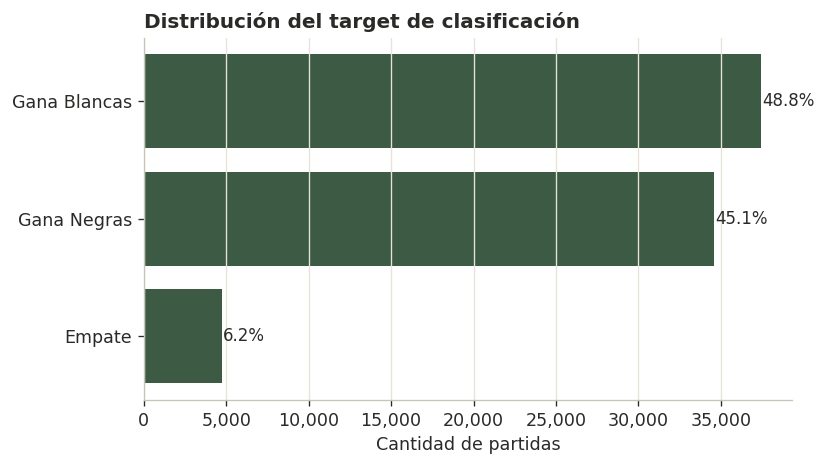

In [13]:
resultado_counts = df_check["resultado"].value_counts()
resultado_pct = 100 * resultado_counts / resultado_counts.sum()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(resultado_counts.index[::-1], resultado_counts.values[::-1], color=ACCENT)
for bar, pct in zip(bars, resultado_pct.values[::-1]):
    ax.text(bar.get_width() + 40, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=10, color=INK)
ax.set_title("Distribución del target de clasificación")
ax.set_xlabel("Cantidad de partidas")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

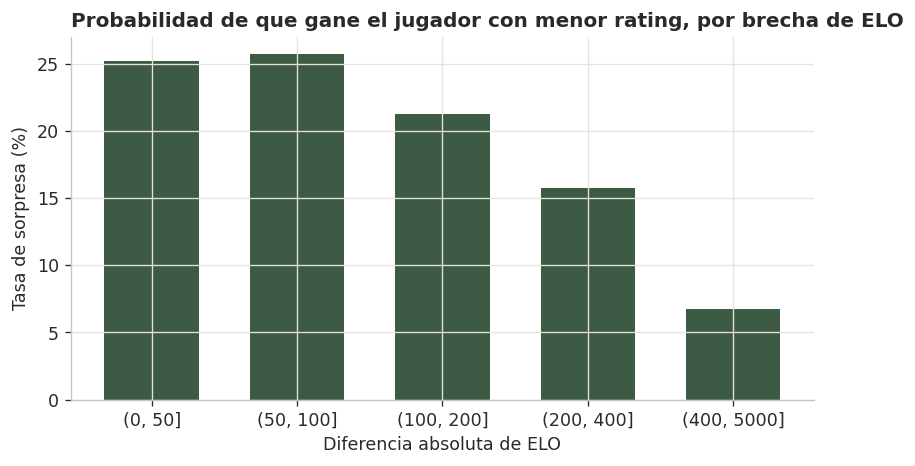

In [14]:
abs_diferencia_elo = df_check["diferencia_elo"].abs()
bins = pd.cut(abs_diferencia_elo, bins=[0, 50, 100, 200, 400, 5000])
tasa_sorpresa_por_brecha = df_check.groupby(bins, observed=True)["es_sorpresa"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(tasa_sorpresa_por_brecha)), tasa_sorpresa_por_brecha.values, color=ACCENT, width=0.65)
ax.set_xticks(range(len(tasa_sorpresa_por_brecha)))
ax.set_xticklabels([str(i) for i in tasa_sorpresa_por_brecha.index], rotation=0)
ax.set_ylabel("Tasa de sorpresa (%)")
ax.set_xlabel("Diferencia absoluta de ELO")
ax.set_title("Probabilidad de que gane el jugador con menor rating, por brecha de ELO")
plt.tight_layout()
plt.show()

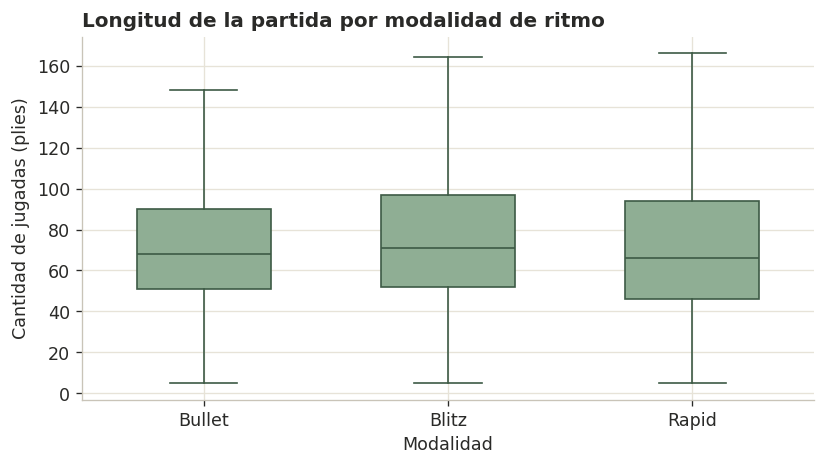

In [15]:
orden_time_class = ["bullet", "blitz", "rapid"]
etiquetas_time_class = ["Bullet", "Blitz", "Rapid"]
datos_box = [df_check.loc[df_check["TimeClass"] == clase, "cantidad_jugadas"] for clase in orden_time_class]

fig, ax = plt.subplots(figsize=(7, 4))
box = ax.boxplot(
    datos_box, tick_labels=etiquetas_time_class, patch_artist=True, showfliers=False, widths=0.55,
)
for patch in box["boxes"]:
    patch.set_facecolor(ACCENT_SOFT)
    patch.set_edgecolor(ACCENT)
for element in ["whiskers", "caps", "medians"]:
    for line in box[element]:
        line.set_color(ACCENT)
ax.set_ylabel("Cantidad de jugadas (plies)")
ax.set_xlabel("Modalidad")
ax.set_title("Longitud de la partida por modalidad de ritmo")
plt.tight_layout()
plt.show()

## 10 · Chequeos de integridad

Verificaciones finales sobre el dataset persistido, no sobre el `df` en memoria.

In [16]:
assert df_check.shape[0] > 1_000, "El volumen final es insuficiente para la entrega"
assert df_check["GameUrl"].is_unique, "Quedaron partidas duplicadas"
assert df_check["resultado"].isin(["Gana Blancas", "Gana Negras", "Empate"]).all(), \
    "resultado tiene valores inesperados"
assert df_check["cantidad_jugadas"].min() >= 5, \
    "Quedaron partidas por debajo del umbral mínimo de plies"
assert df_check[["WhiteElo", "BlackElo"]].isna().sum().sum() == 0, "No debe haber nulos en ELO"
# Same rule as the DAG's criterion 5: TournamentUrl is the only documented null column.
documented_nulls = {"TournamentUrl"}
unexpected_nulls = set(df_check.columns[df_check.isna().any()]) - documented_nulls
assert not unexpected_nulls, f"Nulos no documentados en {sorted(unexpected_nulls)}"
assert (df_check["EsTorneo"] == df_check["TournamentUrl"].notna()).all(),     "EsTorneo debe coincidir con TournamentUrl presente"
assert (df_check["StartTime"] <= df_check["EndTime"]).all(), "Ninguna partida puede terminar antes de empezar"
assert df_check["Termination"].astype("string").str.contains(
    "|".join(sorted(seleccionados)), case=False, na=False
).sum() == 0, "Termination no debe contener usernames"

print("Todos los chequeos de integridad pasaron.")

Todos los chequeos de integridad pasaron.


## Resumen y checklist de los 7 criterios

Pipeline ejecutado de punta a punta contra la PubAPI real de Chess.com, sin pasos manuales, con la misma lógica que corre el DAG de Airflow. El dataset final queda en `data/processed/partidas_ajedrez_clean.parquet`, listo para Entrega 2. Las limitaciones de la Sección 6 y el alcance de la muestra de la Sección 8 quedan documentados para que el modelado de Entrega 3 se plantee sobre la población y la información temporal correctas.

| # | Criterio de la cátedra | Cumplimiento |
|---|---|---|
| 1 | Datos tidy | Una fila por partida, una columna por variable. |
| 2 | Unidad alineada con la pregunta | La partida es exactamente la unidad de análisis. |
| 3 | Algo modelable | `resultado` (clasificación) y `cantidad_jugadas` (regresión). |
| 4 | Descarga automatizada | PubAPI pública, sin intervención manual ni credenciales. |
| 5 | Volumen suficiente | 76.803 partidas limpias (> 1.000). |
| 6 | Columnas informativas | Ratings, color, apertura, ritmo, tiempo, resultado, fecha, hora de inicio y fin, torneo. |
| 7 | Documentación clara | Diccionario de datos y limitaciones documentadas en este notebook. |